<a href="https://colab.research.google.com/github/AstronomekDomansky/-.-1/blob/main/%D0%A1%D0%B8%D0%B8%D0%91%D0%942.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа 2. Введение в NumPy

NumPy — библиотека для **многомерных массивов** и математики над ними. Таблица pandas удобна, когда у столбцов есть имена. Массив NumPy удобен, когда нужно считать быстро: элементы одного типа лежат в памяти подряд, операции выполняются сразу над всем массивом, без цикла `for`.

На занятии: создание массивов, арифметика, агрегаты, срезы, булевы маски. Затем — операции pandas на датасете потребления энергии беспилотным наземным транспортом (как в основном ноутбуке).

**Данные для части с pandas.** [Energy consumption data for package delivery with an Uncrewed Ground Vehicle](https://doi.org/10.1184/R1/13623944.v1) — Choudhry, Lau, Patrikar, Moon, Rodrigues, Gahlaut et al., Carnegie Mellon University, 2021.


**Рисунок. Одномерный массив NumPy: данные одного типа, индекс с нуля**

![Одномерный массив NumPy: данные одного типа, индекс с нуля](https://numpy.org/doc/2.3/_images/np_array_dataones.png)
Источник: документация NumPy, иллюстрация np_array


## Зачем NumPy, если есть список Python

Обычный список хранит ссылки на объекты Python. Массив NumPy хранит числа блоком и считает их на уровне скомпилированного кода. На миллионе элементов разница видна даже без точного бенчмарка.

Ниже — тот же приём, что в версии практики для робототехники: возвести в квадрат миллион чисел циклом и одной операцией `**`.


In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

n = 1_000_000
python_list = list(range(n))
numpy_array = np.arange(n)

start = time.time()
squared_list = []
for x in python_list:
    squared_list.append(x ** 2)
python_time = time.time() - start

start = time.time()
squared_numpy = numpy_array ** 2
numpy_time = time.time() - start

print(f"Список Python (цикл): {python_time:.4f} с")
print(f"NumPy:                {numpy_time:.4f} с")
print(f"Ускорение примерно в {python_time / max(numpy_time, 1e-9):.0f} раз")


Список Python (цикл): 0.2822 с
NumPy:                0.0039 с
Ускорение примерно в 72 раз


Векторизация — не «магия», а отказ от интерпретации каждой итерации в Python. Цена: все элементы одного `dtype`, форма массива фиксирована, гибкость списка (разные типы в одной ячейке) потеряна. Для датчиков и таблиц чисел это как раз нужный компромисс.


---
# 1. Создание и инициализация массивов

`np.array([...], dtype)` собирает массив из списка. Индексация с **нуля**: `mass1[1]` — второй элемент.

Полезные конструкторы:

- `np.zeros((строки, столбцы))` — нули;
- `np.ones((...))` — единицы;
- `np.arange(start, stop, step)` — как `range`, но массив;
- `np.linspace(a, b, n)` — n чисел от a до b включительно;
- `np.copy(a)` или `np.array(a, copy=True)` — независимая копия.

Присваивание `b = a` копию **не** делает: это второе имя того же куска памяти. Изменение `b[0]` тогда меняет и `a`.


**Рисунок. Массивы из нулей, единиц и случайных чисел**

![Массивы из нулей, единиц и случайных чисел](https://numpy.org/doc/stable/_images/np_ones_zeros_random.png)

Источник: документация NumPy, иллюстрация np_ones_zeros_random


In [ ]:
mass1 = np.array([1, 2, 3], int)
mass2 = np.array([4, 5, 6], int)
print("mass1:", mass1)
print("Второй элемент mass1 (индекс 1):", mass1[1])
print("Форма:", mass1.shape, "| число осей ndim:", mass1.ndim, "| тип:", mass1.dtype)


mass1: [1 2 3]
Второй элемент mass1 (индекс 1): 2
Форма: (3,) | число осей ndim: 1 | тип: int64


## Поэлементная арифметика

Операции `+`, `-`, `*`, `/`, `%`, `**` работают **по элементам**: первое с первым, второе со вторым. Это не матричное умножение из линейной алгебры (для него — `np.dot` или оператор `@`).


In [ ]:
print("Сумма:        ", mass1 + mass2)
print("Разность:     ", mass1 - mass2)
print("Произведение: ", mass1 * mass2)
print("Деление:      ", mass1 / mass2)
print("Остаток:      ", mass1 % mass2)
print("Степень:      ", mass1 ** mass2)


Сумма:         [5 7 9]
Разность:      [-3 -3 -3]
Произведение:  [ 4 10 18]
Деление:       [0.25 0.4  0.5 ]
Остаток:       [1 2 3]
Степень:       [  1  32 729]


Двумерный массив задают списком строк. Если умножить матрицу 3×2 на вектор длины 2, NumPy **растянет** вектор по строкам — это broadcasting: каждый столбец умножается на своё число.


**Рисунок. Broadcasting: вектор длины 2 умножается на каждый столбец матрицы**

![Broadcasting: вектор длины 2 умножается на каждый столбец матрицы](https://numpy.org/doc/stable/_images/np_multiply_broadcasting.png)

Источник: документация NumPy, иллюстрация np_multiply_broadcasting


In [ ]:
mass3 = np.array([[1, 2], [3, 4]], float)
mass4 = np.array([[5, 6], [7, 8]], float)
print("Поэлементное произведение двух матриц 2×2:")
print(mass3 * mass4)

mass5 = np.array([[1, 2], [3, 4], [5, 6]], float)
mass6 = np.array([-1, 3], float)
print("Матрица 3×2 * вектор длины 2:")
print(mass5 * mass6)


Поэлементное произведение двух матриц 2×2:
[[ 5. 12.]
 [21. 32.]]
Матрица 3×2 * вектор длины 2:
[[-1.  6.]
 [-3. 12.]
 [-5. 18.]]


In [ ]:
print("Нули 2×4:")
print(np.zeros((2, 4), int))

print("Единицы 2×3:")
a_ones = np.ones((2, 3))
print(a_ones)

print("Ещё единицы 3×2:")
print(np.ones((3, 2)))

print("arange и linspace:")
print(np.arange(0, 10, 2))
print(np.linspace(0, 1, 5))


Нули 2×4:
[[0 0 0 0]
 [0 0 0 0]]
Единицы 2×3:
[[1. 1. 1.]
 [1. 1. 1.]]
Ещё единицы 3×2:
[[1. 1.]
 [1. 1.]
 [1. 1.]]
arange и linspace:
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]


In [ ]:
a = np.array([[1, 2, 3, 4.0],
              [5, 6, 7, 8],
              [9, 10, 11, 12]])
b = np.copy(a)
# эквивалент: b = np.array(a, copy=True)
b[0, 0] = 999
print("Копия изменена:\n", b)
print("Исходник без 999:\n", a)


Копия изменена:
 [[999.   2.   3.   4.]
 [  5.   6.   7.   8.]
 [  9.  10.  11.  12.]]
Исходник без 999:
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]


---
# 2. Базовые операции над массивами

Агрегация сжимает массив в число (или в массив по оси).


**Рисунок. Сумма, минимум и среднее по всему массиву или по оси**

![Сумма, минимум и среднее по всему массиву или по оси](https://numpy.org/doc/stable/_images/np_matrix_aggregation.png)

Источник: документация NumPy, иллюстрация np_matrix_aggregation


- `.sum()`, `.prod()`, `.mean()`, `.min()`, `.max()`;
- `.argmin()` / `.argmax()` — **индекс** экстремума, не само значение;
- `axis=0` — свернуть строки (итог по столбцам), `axis=1` — свернуть столбцы (итог по строкам);
- `sorted(массив)` — отсортированный **список** Python;
- `for x in mass9` — обход **строк** двумерного массива.


In [ ]:
mass7 = np.array([2, 4, 5], float)
print("Сумма =", mass7.sum())
print("Произведение =", mass7.prod())
print("Среднее =", mass7.mean())
print("Минимум =", mass7.min())
print("Индекс минимума =", mass7.argmin())

mass8 = np.array([7, 4, 5, 1], float)
print("Отсортированный:", sorted(mass8))

mass9 = np.array([[1, 2], [3, 4], [5, 6]], float)
print("Построчный обход:")
for x in mass9:
    print(x)

print("Сумма по столбцам axis=0:", mass9.sum(axis=0))
print("Сумма по строкам axis=1:", mass9.sum(axis=1))


Сумма = 11.0
Произведение = 40.0
Среднее = 3.6666666666666665
Минимум = 2.0
Индекс минимума = 0
Отсортированный: [np.float64(1.0), np.float64(4.0), np.float64(5.0), np.float64(7.0)]
Построчный обход:
[1. 2.]
[3. 4.]
[5. 6.]
Сумма по столбцам axis=0: [ 9. 12.]
Сумма по строкам axis=1: [ 3.  7. 11.]


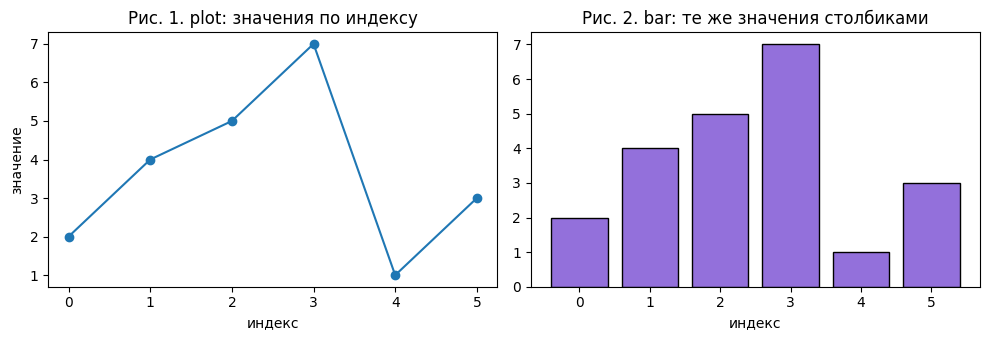

In [ ]:
demo = np.array([2, 4, 5, 7, 1, 3], float)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(demo, marker="o")
axes[0].set_title("Рис. 1. plot: значения по индексу")
axes[0].set_xlabel("индекс")
axes[0].set_ylabel("значение")

axes[1].bar(range(len(demo)), demo, color="mediumpurple", edgecolor="black")
axes[1].set_title("Рис. 2. bar: те же значения столбиками")
axes[1].set_xlabel("индекс")
plt.tight_layout()
plt.show()


Нормализация в отрезок [0, 1] часто нужна перед сравнением признаков с разным масштабом:

$$x' = (x - x_{min}) / (x_{max} - x_{min})$$

Если все элементы равны, знаменатель нулевой — массив лучше вернуть как есть.


In [ ]:
def normalize_01(x):
    x = np.asarray(x, dtype=float)
    xmin, xmax = x.min(), x.max()
    if xmax == xmin:
        return x.copy()
    return (x - xmin) / (xmax - xmin)

demo2 = np.array([[2.0, 4.0], [6.0, 8.0]])
print("До:\n", demo2)
print("После нормализации:\n", normalize_01(demo2))
print("min/max после:", normalize_01(demo2).min(), normalize_01(demo2).max())


До:
 [[2. 4.]
 [6. 8.]]
После нормализации:
 [[0.         0.33333333]
 [0.66666667 1.        ]]
min/max после: 0.0 1.0


---
# 3. Индексация и срезы в многомерных массивах

Синтаксис похож на списки Python, но работает по **каждой оси** отдельно. Запятая разделяет оси: `arr[строка, столбец]`.


**Рисунок. Индексация и срезы двумерного массива**

![Индексация и срезы двумерного массива](https://numpy.org/doc/stable/_images/np_indexing.png)

Источник: документация NumPy, иллюстрация np_indexing


- `arr[0]` — первая строка;
- `arr[2, 3]` — строка 2, столбец 3 (с нуля);
- `arr[-1]` — последняя строка;
- `arr[0:2]` — первые две строки;
- `arr[:, 1:3]` — все строки, столбцы 1 и 2 (`:` значит «взять всё»);
- шаг `arr[::2]`, разворот `arr[::-1]`;
- главная диагональ: цикл `for i in range(n): arr[i, i] = ...` или `np.fill_diagonal`.


In [ ]:
arr = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
])
print(arr)
print("\nПервая строка:", arr[0])
print("Элемент [2, 3]:", arr[2, 3])
print("Последняя строка:", arr[-1])
print("\nПервые две строки:\n", arr[0:2])
print("\nСтолбцы 1 и 2:\n", arr[:, 1:3])
print("\nС 2-й строки и с 3-го столбца:\n", arr[1:, 2:])
print("\nКаждая вторая строка:\n", arr[::2])
print("\nКаждый второй столбец:\n", arr[:, ::2])
print("\nСтроки в обратном порядке:\n", arr[::-1])


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Первая строка: [1 2 3 4]
Элемент [2, 3]: 12
Последняя строка: [ 9 10 11 12]

Первые две строки:
 [[1 2 3 4]
 [5 6 7 8]]

Столбцы 1 и 2:
 [[ 2  3]
 [ 6  7]
 [10 11]]

С 2-й строки и с 3-го столбца:
 [[ 7  8]
 [11 12]]

Каждая вторая строка:
 [[ 1  2  3  4]
 [ 9 10 11 12]]

Каждый второй столбец:
 [[ 1  3]
 [ 5  7]
 [ 9 11]]

Строки в обратном порядке:
 [[ 9 10 11 12]
 [ 5  6  7  8]
 [ 1  2  3  4]]


In [ ]:
seq = np.arange(1, 16)
print("1…15:", seq)
print("\nПервые 5:", seq[:5])
print("\nКаждый второй:", seq[::2])
print("\nПоследние 5 в обратном порядке:", seq[-5:][::-1])

m = np.arange(1, 37).reshape(6, 6)
print("\nМассив 6×6:\n", m)
print("\n2-я строка (индекс 1):", m[1])
print("\nПоследние два столбца:\n", m[:, -2:])
m2 = m.copy()
np.fill_diagonal(m2, 0)
print("\nГлавная диагональ обнулена:\n", m2)


1…15: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]

Первые 5: [1 2 3 4 5]

Каждый второй: [ 1  3  5  7  9 11 13 15]

Последние 5 в обратном порядке: [15 14 13 12 11]

Массив 6×6:
 [[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [13 14 15 16 17 18]
 [19 20 21 22 23 24]
 [25 26 27 28 29 30]
 [31 32 33 34 35 36]]

2-я строка (индекс 1): [ 7  8  9 10 11 12]

Последние два столбца:
 [[ 5  6]
 [11 12]
 [17 18]
 [23 24]
 [29 30]
 [35 36]]

Главная диагональ обнулена:
 [[ 0  2  3  4  5  6]
 [ 7  0  9 10 11 12]
 [13 14  0 16 17 18]
 [19 20 21  0 23 24]
 [25 26 27 28  0 30]
 [31 32 33 34 35  0]]


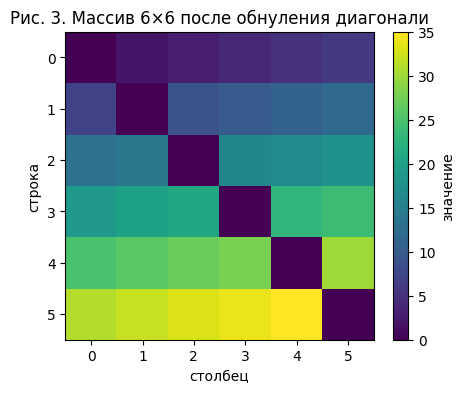

In [ ]:
plt.figure(figsize=(5, 4))
plt.imshow(m2, cmap="viridis")
plt.colorbar(label="значение")
plt.title("Рис. 3. Массив 6×6 после обнуления диагонали")
plt.xlabel("столбец")
plt.ylabel("строка")
plt.show()


## Булева маска

Маска — массив `True`/`False` той же формы. Условие `arr > 40` строит маску. `arr[mask]` оставляет элементы, где `True` (результат становится одномерным). Присваивание `arr[mask] = -1` точечно заменяет значения.


In [ ]:
arr = np.array([[10, 20, 30],
                [40, 50, 60],
                [70, 80, 90]])
mask = arr > 40
print("Маска:\n", mask)
print("\nЭлементы больше 40:", arr[mask])

arr2 = arr.copy()
arr2[mask] = -1
print("\nЗамена на -1:\n", arr2)


Маска:
 [[False False False]
 [False  True  True]
 [ True  True  True]]

Элементы больше 40: [50 60 70 80 90]

Замена на -1:
 [[10 20 30]
 [40 -1 -1]
 [-1 -1 -1]]


---
# 4. Операции над данными в библиотеке Pandas

Массив удобен для чистой математики. Когда у столбцов есть имена и разные типы, возвращаемся к pandas: `head`, `tail`, `info`, срез строк, уникальные значения.

Датасет — потребление энергии беспилотником при доставке посылок. Если `gdown` недоступен, скачайте CSV вручную и укажите путь в `pd.read_csv`.


In [ ]:
# !pip install gdown -q
import gdown
import pandas as pd

file_id = "1qq6rk9YwRE_AwxUO7_xbRwq0OJPwtYsb"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "robot_dataset.csv", quiet=False)
df = pd.read_csv("robot_dataset.csv")
df.head()


Downloading...
From (original): https://drive.google.com/uc?id=1qq6rk9YwRE_AwxUO7_xbRwq0OJPwtYsb
From (redirected): https://drive.google.com/uc?id=1qq6rk9YwRE_AwxUO7_xbRwq0OJPwtYsb&confirm=t&uuid=7a8c3de4-ad34-4aed-a03f-33705d545d5e
To: /content/robot_dataset.csv
100%|██████████| 174M/174M [00:02<00:00, 63.3MB/s]


,test,time,battery_voltage_computer,battery_current_computer,battery_voltage_husky,battery_current_husky,position_x,position_y,position_z,orientation_x,...,angular_y,angular_z,linear_acceleration_x,linear_acceleration_y,linear_acceleration_z,temperature,humidity,route,speed,payload
0,1,0.0,25.687559,-3.265014,23.730831,-5.500566,-79.945528,40.44369,247.112992,-0.009318,...,-0.001370,0.001419,-0.202699,-0.182956,-9.812503,30.106937,28.325180,A,1.0,12
1,1,0.1,25.686302,-3.226152,23.717432,-5.399637,-79.945528,40.44369,247.114304,-0.009318,...,-0.002070,0.001642,-0.195739,-0.183969,-9.820614,30.106937,27.977432,A,1.0,12
2,1,0.2,25.687559,-3.219675,23.730831,-5.096851,-79.945528,40.44369,247.115688,-0.009319,...,0.000148,-0.003457,-0.198949,-0.184708,-9.810820,30.111963,28.134895,A,1.0,12
3,1,0.3,25.696354,-3.109566,23.821280,-5.130495,-79.945528,40.44369,247.118170,-0.009311,...,-0.001885,-0.002250,-0.197439,-0.182529,-9.796706,30.116987,28.123913,A,1.0,12
4,1,0.4,25.620972,-2.980026,23.797831,-5.265066,-79.945528,40.44369,247.119541,-0.009312,...,-0.001743,-0.000586,-0.197280,-0.182930,-9.802644,30.116987,28.096743,A,1.0,12


In [ ]:
print("Последние 3 строки:")
display(df.tail(3))

print("Сводка типов и пропусков:")
df.info()


Последние 3 строки:


,test,time,battery_voltage_computer,battery_current_computer,battery_voltage_husky,battery_current_husky,position_x,position_y,position_z,orientation_x,...,angular_y,angular_z,linear_acceleration_x,linear_acceleration_y,linear_acceleration_z,temperature,humidity,route,speed,payload
386366,113,453.8,25.105864,-1.069311,24.822905,-4.278210,-79.946131,40.442014,252.793372,0.013492,...,-0.000593,0.001043,0.041431,-0.339294,-9.802654,22.761349,84.010849,D,1.0,0
386367,113,453.9,25.095814,-1.101696,24.829605,-4.367924,-79.946131,40.442014,252.822278,0.013491,...,0.002650,-0.000394,0.039757,-0.336217,-9.802904,22.761349,84.000336,D,1.0,0
386368,113,454.0,25.097071,-1.069311,24.879854,-4.244567,-79.946131,40.442014,252.827333,0.013491,...,-0.003068,-0.002877,0.039091,-0.339882,-9.802012,22.756325,84.015579,D,1.0,0


Сводка типов и пропусков:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386369 entries, 0 to 386368
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   test                      386369 non-null  int64  
 1   time                      386369 non-null  float64
 2   battery_voltage_computer  386369 non-null  float64
 3   battery_current_computer  386369 non-null  float64
 4   battery_voltage_husky     386369 non-null  float64
 5   battery_current_husky     386369 non-null  float64
 6   position_x                386369 non-null  float64
 7   position_y                386369 non-null  float64
 8   position_z                386369 non-null  float64
 9   orientation_x             386369 non-null  float64
 10  orientation_y             386369 non-null  float64
 11  orientation_z             386369 non-null  float64
 12  orientation_w             386369 non-null  float64
 13  velocity_x        

Для примера выведем строки с **нечётными** номерами позиций: `df.iloc[1::2]` — старт с 1, шаг 2.

`df.columns` — имена всех признаков.

`unique()` — какие значения принимает столбец, без повторов.

`value_counts()` — сколько раз встретилось каждое значение.

`df.apply(np.max)` прогоняет `np.max` по каждому столбцу (для текста максимум — «последняя» строка в лексикографическом порядке).


In [ ]:
print("Нечётные строки (начало):")
display(df.iloc[1::2].head())

print("Имена столбцов:")
print(df.columns.tolist())

print("Максимум по столбцам (apply np.max):")
print(df.apply(np.max))


Нечётные строки (начало):


,test,time,battery_voltage_computer,battery_current_computer,battery_voltage_husky,battery_current_husky,position_x,position_y,position_z,orientation_x,...,angular_y,angular_z,linear_acceleration_x,linear_acceleration_y,linear_acceleration_z,temperature,humidity,route,speed,payload
1,1,0.1,25.686302,-3.226152,23.717432,-5.399637,-79.945528,40.443690,247.114304,-0.009318,...,-0.002070,0.001642,-0.195739,-0.183969,-9.820614,30.106937,27.977432,A,1.0,12
3,1,0.3,25.696354,-3.109566,23.821280,-5.130495,-79.945528,40.443690,247.118170,-0.009311,...,-0.001885,-0.002250,-0.197439,-0.182529,-9.796706,30.116987,28.123913,A,1.0,12
5,1,0.5,25.677507,-3.116043,23.871529,-5.096851,-79.945528,40.443690,247.121611,-0.009313,...,0.001370,-0.000609,-0.199234,-0.183626,-9.807267,30.106937,28.113276,A,1.0,12
7,1,0.7,25.718967,-3.044796,23.673883,-5.220209,-79.945528,40.443690,247.124375,-0.009314,...,0.000264,-0.000237,-0.201074,-0.183315,-9.820093,30.116987,28.113045,A,1.0,12
9,1,0.9,25.651125,-3.329784,23.854778,-5.063209,-79.945528,40.443689,247.130009,-0.009307,...,0.002392,0.001319,-0.200857,-0.184433,-9.805352,30.106937,28.189346,A,1.0,12


Имена столбцов:
['test', 'time', 'battery_voltage_computer', 'battery_current_computer', 'battery_voltage_husky', 'battery_current_husky', 'position_x', 'position_y', 'position_z', 'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w', 'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y', 'angular_z', 'linear_acceleration_x', 'linear_acceleration_y', 'linear_acceleration_z', 'temperature', 'humidity', 'route', 'speed', 'payload']
Максимум по столбцам (apply np.max):
test                               113
time                             812.0
battery_voltage_computer     68.913162
battery_current_computer      2.176655
battery_voltage_husky        27.308882
battery_current_husky       131.481796
position_x                  -79.943878
position_y                   40.445337
position_z                  288.598551
orientation_x                 0.176471
orientation_y                  0.04741
orientation_z                 0.999995
orientation_w                 0.99

In [ ]:
if "temperature" in df.columns:
    col = "temperature"
else:
    col = df.select_dtypes(include="number").columns[0]
    print("Столбца temperature нет, берём:", col)

print("Уникальные значения:", df[col].unique())
print()
print("Как часто встречаются (первые 15):")
print(df[col].value_counts().head(15))


Уникальные значения: [30.10693741 30.11196327 30.11698723 ... 22.54028702 22.55033493
 22.55535889]

Как часто встречаются (первые 15):
temperature
21.575661    1624
21.585711    1431
21.666094    1141
21.565613    1118
21.656046    1023
21.595758     889
21.475180     886
21.645998     883
21.555565     882
21.796721     836
18.892855     813
21.485228     812
21.806768     788
18.882807     782
21.786673     761
Name: count, dtype: int64


Столбец как массив: `df[col].to_numpy()`. Дальше доступны `.mean()`, маски, гистограмма. Если уникальных значений мало, столбец скорее округлённый отсчёт, чем непрерывный датчик с высокой точностью — это видно и по `value_counts`, и по столбчатой диаграмме частот.


mean / min / max: 13.62242450907771 -0.964374542236328 35.69442367553711


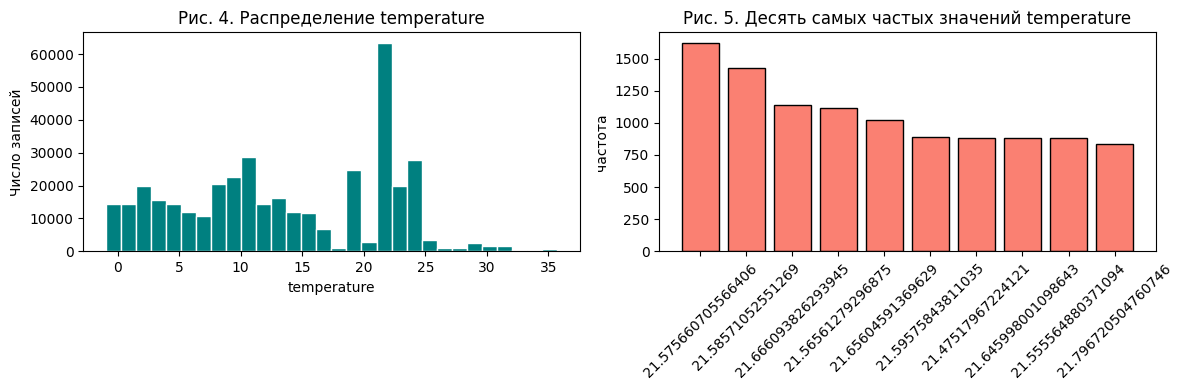

In [ ]:
values = df[col].to_numpy(dtype=float)
print("mean / min / max:", values.mean(), values.min(), values.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(values, bins=30, color="teal", edgecolor="white")
axes[0].set_title(f"Рис. 4. Распределение {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Число записей")

top10 = df[col].value_counts().head(10)
axes[1].bar([str(x) for x in top10.index], top10.values, color="salmon", edgecolor="black")
axes[1].set_title(f"Рис. 5. Десять самых частых значений {col}")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("частота")
plt.tight_layout()
plt.show()


## Добавление столбца и арифметика в таблице

Как на практике 1: случайный столбец, переименование, удаление. Если в данных есть несколько числовых каналов (например `IMF_1` и `IMF_2` в других версиях занятия), их можно сложить в новый признак. Здесь, если подходящих имён нет, сложим два первых числовых столбца — тот же приём.


In [ ]:
df_work = df.copy()
df_work["New_1"] = np.random.randint(1, 100, size=len(df_work))
df_work = df_work.rename(columns={"New_1": "Changed_1"})
df_work = df_work.drop(columns=["Changed_1"])

num_cols = df_work.select_dtypes(include="number").columns.tolist()
print("Числовые столбцы:", num_cols[:8])
if len(num_cols) >= 2:
    a, b = num_cols[0], num_cols[1]
    df_work["sum_demo"] = df_work[a] + df_work[b]
    print(f"Столбец sum_demo = {a} + {b}")
    display(df_work[[a, b, "sum_demo"]].head())


Числовые столбцы: ['test', 'time', 'battery_voltage_computer', 'battery_current_computer', 'battery_voltage_husky', 'battery_current_husky', 'position_x', 'position_y']
Столбец sum_demo = test + time


,test,time,sum_demo
0,1,0.0,1.0
1,1,0.1,1.1
2,1,0.2,1.2
3,1,0.3,1.3
4,1,0.4,1.4
